In [1]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
#data loading

data1 = pd.read_csv('train.csv')
data2 = pd.read_csv('test.csv')

train_df = data1.copy()
test_df = data2.copy()

print("First 5 rows of train_df: \n", train_df.head())

print("First 5 rows of test_df: \n", test_df.head())

First 5 rows of train_df: 
    id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0              

In [3]:
train_df = train_df.drop(columns=['id'], axis=1)

test_id_placeholder = test_df['id']
test_df = test_df.drop(columns=['id'], axis=1)

In [4]:
#feature engineering

train_df['in_relationship'] = (train_df['marital_status'] == 'Married').astype(int)
test_df['in_relationship'] = (test_df['marital_status'] == 'Married').astype(int)

train_df['has_studied'] = train_df['education_level'].isin(["Bachelor's", "High School", "Master's", "PhD"]).astype(int)
test_df['has_studied'] = test_df['education_level'].isin(["Bachelor's", "High School", "Master's", "PhD"]).astype(int)

train_df['is_employed'] = train_df['employment_status'].isin(['Employed', 'Self-Employed']).astype(int)
test_df['is_employed'] = test_df['employment_status'].isin(['Employed', 'Self-Employed']).astype(int)

train_df['in_debt'] = (train_df['loan_purpose'] == 'Debt consolidation').astype(int)
test_df['in_debt'] = (test_df['loan_purpose'] == 'Debt consolidation').astype(int)

In [5]:
train_df

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,in_relationship,has_studied,is_employed,in_debt
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0,1,0,0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,1,1,1,1
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0,1,1,1
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0,1,1,1
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,0,1,1,0
593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,0,1,1,1
593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,1,1,1,1
593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,0,1,1,1


In [6]:
gender_map = {'Male': 0, 'Female': 1, 'Other': 2}

train_df['gender'] = train_df['gender'].map(gender_map)
test_df['gender'] = test_df['gender'].map(gender_map)

In [7]:
train_df = train_df.drop(columns=['marital_status', 'education_level', 'employment_status', 'loan_purpose'])
test_df = test_df.drop(columns=['marital_status', 'education_level', 'employment_status', 'loan_purpose'])

In [10]:
from category_encoders import TargetEncoder

encoder = TargetEncoder()

train_df['grade_encoded'] = encoder.fit_transform(
    train_df['grade_subgrade'],
    train_df['loan_paid_back']
)

test_df['grade_encoded'] = encoder.transform(
    test_df['grade_subgrade']
)

In [12]:
train_df = train_df.drop(columns='grade_subgrade')
test_df = test_df.drop(columns='grade_subgrade')

In [15]:
target_placeholder = train_df.pop('loan_paid_back')

train_df['loan_paid_back'] = target_placeholder

In [16]:
num = train_df.select_dtypes(include='number')

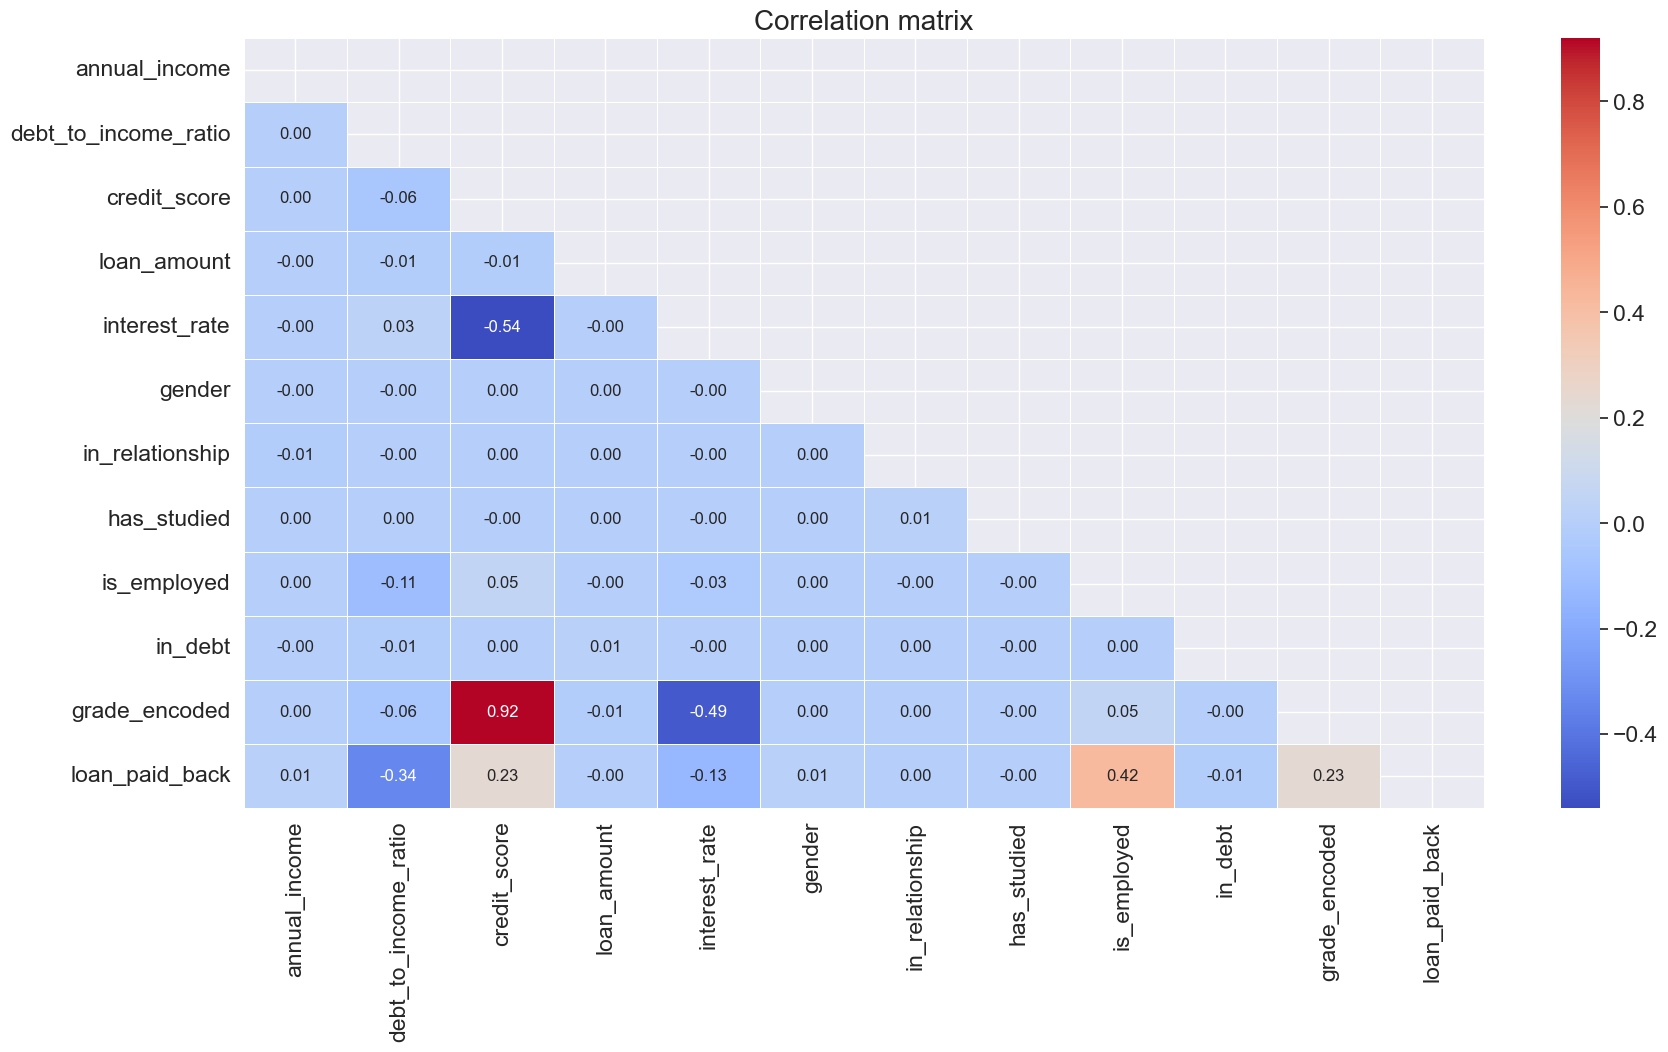

In [17]:
num1 = round(num.corr(), 2)

# Correlation Matrix-Heatmap Plot
mask = np.zeros_like(num1)
mask[np.triu_indices_from(mask)] = True # optional, to hide repeat half of the matrix

f, ax = plt.subplots(figsize=(20, 10))
sns.set_theme(font_scale=1.5) # increase font size

ax = sns.heatmap(num1, mask=mask, annot=True, annot_kws={"size": 12}, linewidths=.5, cmap="coolwarm", fmt=".2f", ax=ax) # round to 2 decimal places
ax.set_title("Correlation matrix", fontsize=20) # add title
plt.show()


In [18]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X = train_df.drop(columns='loan_paid_back')
y = train_df['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


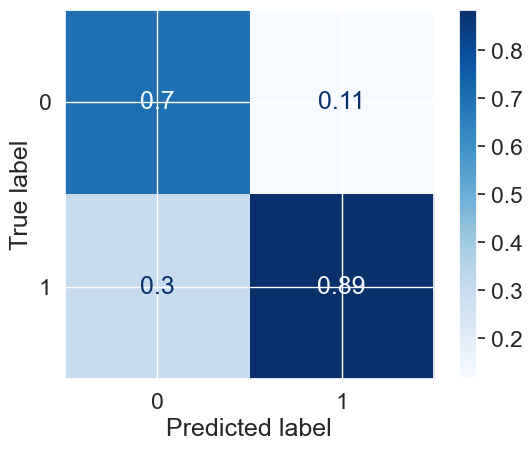

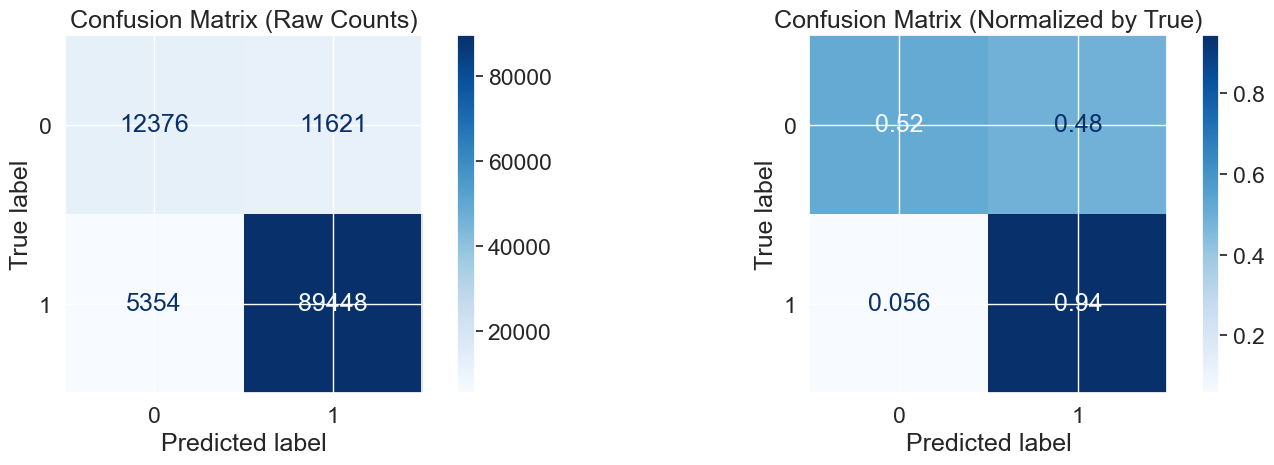

In [20]:
y_true = y_test

y_pred = xgb_model.predict(X_test)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred, normalize='pred')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

# Confusion matrix with different normalization options
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Raw counts
cm_raw = confusion_matrix(y_true, y_pred)
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw)
disp_raw.plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix (Raw Counts)')

# Normalized by true labels (shows recall)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(ax=ax2, cmap='Blues')
ax2.set_title('Confusion Matrix (Normalized by True)')

plt.tight_layout()
plt.show()


In [21]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Basic metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-Score:", f1_score(y_true, y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.8571115918484162
Precision: 0.8850191453363544
Recall: 0.9435243982194469
F1-Score: 0.9133358179618218

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.52      0.59     23997
         1.0       0.89      0.94      0.91     94802

    accuracy                           0.86    118799
   macro avg       0.79      0.73      0.75    118799
weighted avg       0.85      0.86      0.85    118799



In [ ]:
# X_submission = test_df.copy()

# test_pred = xgb_model.predict(test_df)

# submission_df = pd.DataFrame({
#     "id": test_id_placeholder,
#     "loan_paid_back": test_pred
# })

# submission_df.to_csv('submission3.csv',index=False)
# print("Success!")

Success!
